In [3]:
!pip install automathon graphviz

from automathon import DFA
from IPython.display import Image, display

  Attempting uninstall: graphviz
    Found existing installation: graphviz 0.21
    Uninstalling graphviz-0.21:
      Successfully uninstalled graphviz-0.21


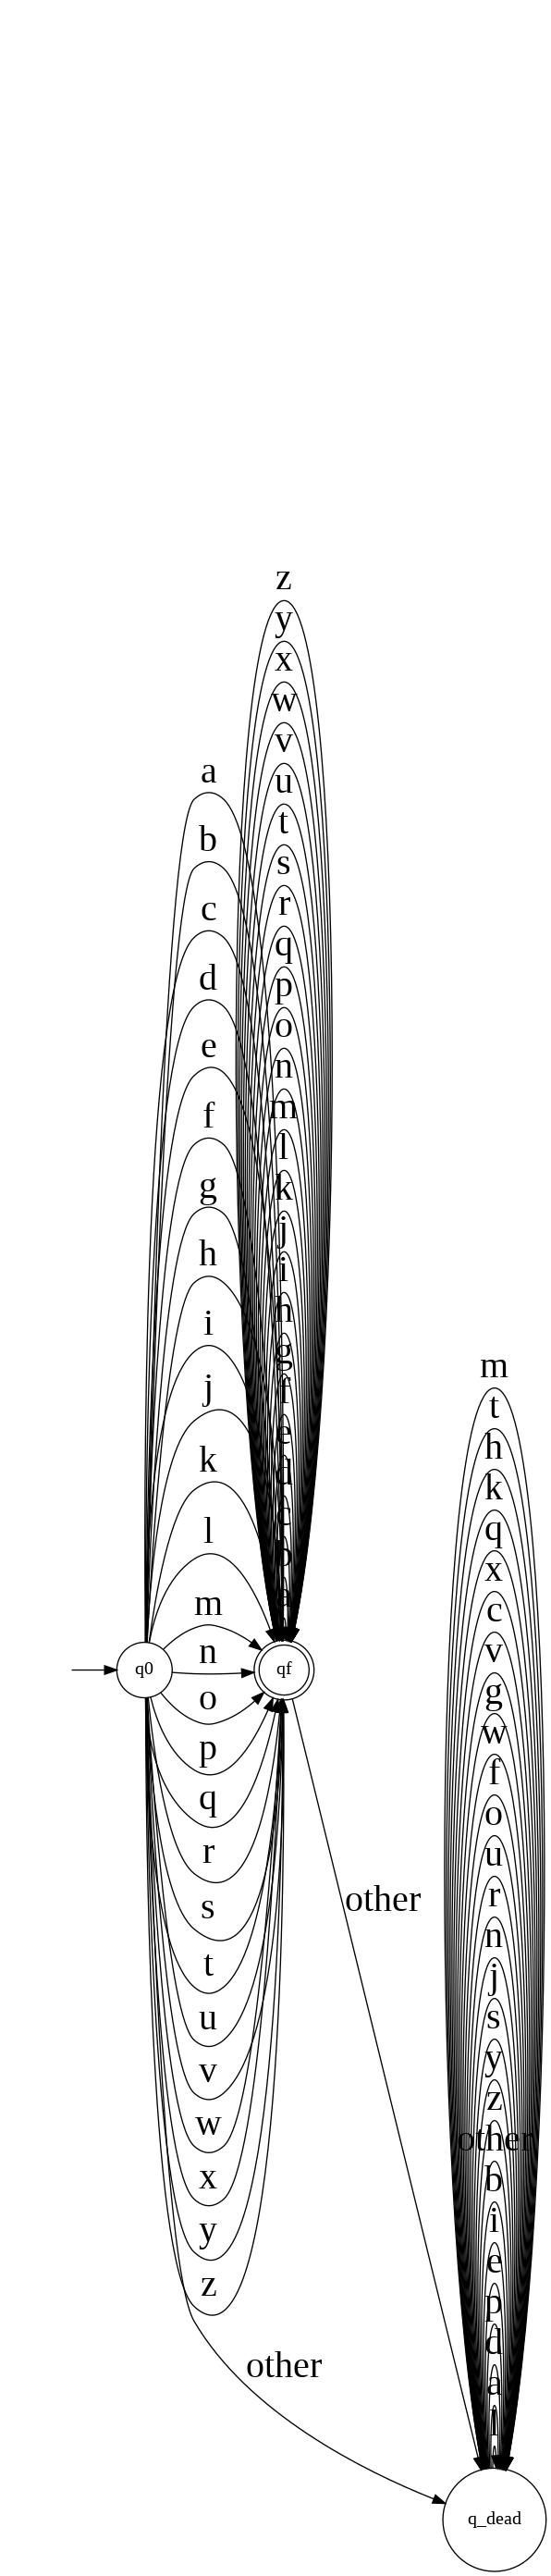


verifying using autometa
cat -> Accepted
dog -> Accepted
a -> Accepted
zebra -> Accepted
dog1 -> Not Accepted 
1dog -> Not Accepted 
DogHouse -> Not Accepted 
Dog_house -> Not Accepted 
 cats -> Not Accepted 


In [4]:
# def dfa_validate(word):
#     for i, ch in enumerate(word):
#       if not 'a' <= ch <= 'z':
#         return False
#     return True

test_words = [
    "cat", "dog", "a", "zebra",
    "dog1", "1dog", "DogHouse", "Dog_house", " cats"
]

# for word in test_words:
#     if dfa_validate(word):
#         print(f"{word} -> Accepted")
#     else:
#         print(f"{word} -> Not Accepted ")

q = {'q0', 'qf', 'q_dead'}
sigma = set([chr(c) for c in range(ord('a'), ord('z')+1)] + ['other'])
delta = {
    'q0': dict(**{ch: 'qf' for ch in [chr(c) for c in range(ord('a'), ord('z')+1)]},
               **{'other': 'q_dead'}),
    'qf': dict(**{ch: 'qf' for ch in [chr(c) for c in range(ord('a'), ord('z')+1)]},
               **{'other': 'q_dead'}),
    'q_dead': {ch: 'q_dead' for ch in sigma}
}
initial_state = 'q0'
f = {'qf'}

automata = DFA(q, sigma, delta, initial_state, f)
automata.is_valid()    # True
automata.view(
    file_name="word_validate_DFA",
    node_attr={'fontsize': '15'},
    edge_attr={'fontsize': '30pt'}
)
image_path = "/content/word_validate_DFA.gv.png"

display(Image(filename=image_path))
print("\nverifying using autometa")
for word in test_words:
    if automata.accept(word):
        print(f"{word} -> Accepted")
    else:
        print(f"{word} -> Not Accepted ")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [5]:
with open("brown_nouns.txt", "r", encoding="utf-8") as f:
    for line in f:
      line = line[:-1]
      if(automata.accept(line)):
        continue
      else:
        print(f"{line} -> Not Accepted ")


Implementation -> Not Accepted 
Failure -> Not Accepted 
Attorneys -> Not Accepted 
GOP -> Not Accepted 
$100 -> Not Accepted 
$30 -> Not Accepted 
$50 -> Not Accepted 
$10 -> Not Accepted 
Committee -> Not Accepted 
Senators -> Not Accepted 
$451,500 -> Not Accepted 
$157,460 -> Not Accepted 
$88,000 -> Not Accepted 
TEA -> Not Accepted 
Money -> Not Accepted 
$1,000 -> Not Accepted 
$12 -> Not Accepted 
State -> Not Accepted 
Opponents -> Not Accepted 
$5,000,000 -> Not Accepted 
$15,000,000 -> Not Accepted 
Statements -> Not Accepted 
College -> Not Accepted 
Principals -> Not Accepted 
State -> Not Accepted 
ADC -> Not Accepted 
ADC -> Not Accepted 
ADC -> Not Accepted 
ADC -> Not Accepted 
ADC -> Not Accepted 
ADC -> Not Accepted 
ADC -> Not Accepted 
Extension -> Not Accepted 
ADC -> Not Accepted 
Research -> Not Accepted 
Contempt -> Not Accepted 
$37 -> Not Accepted 
$4,800 -> Not Accepted 
$5,000 -> Not Accepted 
Officials -> Not Accepted 
$10 -> Not Accepted 
Hospital -> Not 

In [8]:
import string
from typing import Tuple

VOWELS = set("aeiou")
SIBILANTS = ("s", "z", "x")
DIGRAPHS = ("ch", "sh")
ALPHABET = set(string.ascii_lowercase)

class FST:
    def __init__(self):
        pass

    def _analyze(self, w: str) -> Tuple[bool, str, str]:


        if not w.endswith("s"):
            return True, w, "SG"

        if w.endswith("ies") and len(w) >= 4:
            # letter before 'ies'
            prev = w[-4]
            if prev not in VOWELS:
                root = w[:-3] + "y"
                return True, root, "PL"
            # if preceding letter is a vowel, 'ies' might actually be a stem like 'pie'->'pies' (but rare)
            # fall through to other checks

        # 2) endswith 'es' (potential e-insertion). Two common possibilities:
        #    a) true e-insertion: root ends with sibilant/digraph (x,z,s, ch, sh) -> drop 'es'
        #    b) stems that end with 'ie' or vowel: movie -> movies (drop only 's', root endswith 'ie')
        if w.endswith("es") and len(w) >= 3:
            cand_drop_es = w[:-2]  # candidate root if we drop 'es' (eg. foxes -> fox)
            # Accept if cand_drop_es orthographically requires 'es' (x,z,s, ch, sh)
            cond_es_expected = (
                cand_drop_es.endswith(SIBILANTS) or
                cand_drop_es.endswith("s") or
                any(cand_drop_es.endswith(d) for d in DIGRAPHS)
            )
            if cond_es_expected:
                return True, cand_drop_es, "PL"
            # Otherwise check if dropping only 's' yields a stem that ends with 'ie' or a vowel,
            # e.g., movies -> movie (movie endswith 'ie')
            cand_drop_s = w[:-1]
            if cand_drop_s.endswith("ie") or (len(cand_drop_s) >= 1 and cand_drop_s[-1] in VOWELS):
                return True, cand_drop_s, "PL"
            # If neither condition holds, don't accept here — fallthrough to more checks

        # 3) endswith single 's' -> simple -s plural, but ensure base doesn't require 'es' orthographically
        cand = w[:-1]
        if cand:
            # if base would require 'es' (x,z,s,ch,sh), then having only 's' is invalid
            if cand.endswith(SIBILANTS) or cand.endswith("s") or any(cand.endswith(d) for d in DIGRAPHS):
                return False, "", ""
            # otherwise accept as simple -s plural
            return True, cand, "PL"

        # Otherwise invalid
        return False, "", ""

    def accept(self, word: str) -> bool:
        ok, _, _ = self._analyze(word)
        return ok

    def run(self, word: str) -> str:
        ok, root, tag = self._analyze(word)
        if not ok:
            return "Invalid Word"
        return f"{root}+N+{tag}"
fst = FST()

test_words = [
    "cat",      # Simple singular
    "cats",     # Simple plural
    "fox",      # E-insertion singular
    "foxes",    # E-insertion plural
    "watch",    # E-insertion singular
    "watches",  # E-insertion plural
    "try",      # Y-replacement singular
    "tries",    # Y-replacement plural
    "bus",      # E-insertion singular
    "buses",    # E-insertion plural
    "foxs",     # Invalid word
    "trys"      # Invalid word
]
with open("brown_nouns.txt", "r", encoding="utf-8") as f:
    for line in f:
      line = line[:-1]
      if(automata.accept(line)):
        output = fst.run(line)
        print(f"{line:<10} -> {output}")
      else:
        print(f"{line} -> INVALID ")


Streaming output truncated to the last 5000 lines.
street     -> street+N+SG
clothes    -> clothe+N+PL
release    -> release+N+SG
head       -> head+N+SG
moments    -> moment+N+PL
clothes    -> clothe+N+PL
bench      -> bench+N+SG
shoe       -> shoe+N+SG
plenty     -> plenty+N+SG
guys       -> guy+N+PL
leagues    -> league+N+PL
guys       -> guy+N+PL
club       -> club+N+SG
hell       -> hell+N+SG
right      -> right+N+SG
thing      -> thing+N+SG
thing      -> thing+N+SG
job        -> job+N+SG
job        -> job+N+SG
outfielders -> outfielder+N+PL
way        -> way+N+SG
interest   -> interest+N+SG
product    -> product+N+SG
insularity -> insularity+N+SG
reading    -> reading+N+SG
religion   -> religion+N+SG
subject    -> subject+N+SG
religion   -> religion+N+SG
tomes      -> tome+N+PL
papers     -> paper+N+PL
birthday   -> birthday+N+SG
store      -> store+N+SG
mother     -> mother+N+SG
image      -> image+N+SG
god        -> god+N+SG
day        -> day+N+SG
mother     -> mother+N+SG
pres

In [16]:
fst.run("trash")

'trash+N+SG'